In [ ]:
import illustris_python as il
import glob
import os
import numpy as np
import h5py
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd


: 

In [2]:
#LOADING FILE

directory = '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/'


files = glob.glob(os.path.join(directory, '*'))

print(files)

nums = []
for file in files:
    num = file.split('.')[-2]
    nums.append(int(num))

mapping = np.argsort(nums)

files = np.array(files)[mapping]

file = files[0]


with h5py.File(file, "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    # get first object name/key; may or may NOT be a group
    group_key = list(f.keys())[1]

    subhalo_key = list(f.keys())[5]


    #Get the HDF5 group; key needs to be a group name from above
    group = f[group_key]


    #Checkout what keys are inside that group.
    for key in group.keys():
        print(key)

    
    group = f[subhalo_key]


    for key in group.keys():
        print(key)
    
    


#group catalogue = table with derived quantities about the halo / galaxy . you have the equivalent with NH


['/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.582.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.345.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.15.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.65.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.286.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.428.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.110.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.394.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.203.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.629.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_tab_099.241.hdf5', '/mnt/extraspace/rstiskalek/TNG50-1/output/groups_099/fof_subhalo_

dict_keys(['count', 'SubhaloMass', 'SubhaloSFRinRad'])
(5688113,)
5688113


Text(0, 0.5, 'Star Formation Rate [$M_\\odot / yr$]')

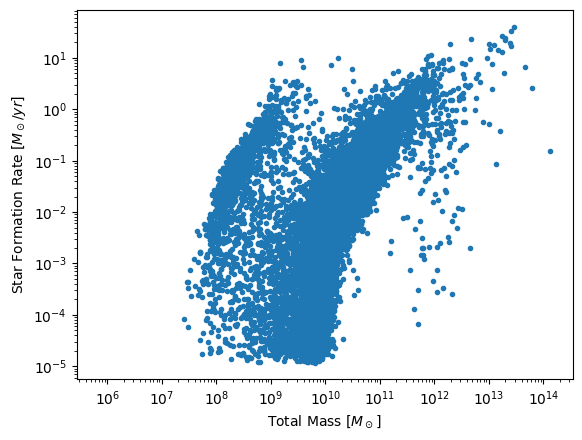

In [3]:
#TRYING PLOT FROM WEBSITE EXAMPLE

basePath = '/mnt/extraspace/rstiskalek/TNG50-1/output'
fields = ['SubhaloMass','SubhaloSFRinRad']
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=fields)

print(subhalos.keys())
print(subhalos['SubhaloMass'].shape)

mass_msun = subhalos['SubhaloMass'] * 1e10

print(len(mass_msun))
plt.plot(mass_msun,subhalos['SubhaloSFRinRad'],'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Mass [$M_\odot$]')
plt.ylabel('Star Formation Rate [$M_\odot / yr$]')

In [4]:
#SNAPSHOT GIVES INDIVIDUAL PARTICLE INFORMATION. GROUPCAT GIVES INFORMATION ABOUT HALOS

stars = il.snapshot.loadSubhalo(basePath,99,536684,'stars')
print(stars.keys())


for i in range(3):
    print(np.min(stars['Coordinates'][:,i]), np.max(stars['Coordinates'][:,i]))

dict_keys(['count', 'BirthPos', 'BirthVel', 'Coordinates', 'GFM_InitialMass', 'GFM_Metallicity', 'GFM_Metals', 'GFM_MetalsTagged', 'GFM_StellarFormationTime', 'GFM_StellarPhotometrics', 'Masses', 'ParticleIDs', 'Potential', 'StellarHsml', 'SubfindDMDensity', 'SubfindDensity', 'SubfindHsml', 'SubfindVelDisp', 'Velocities'])
2173.083858708682 2179.6216534056484
5497.946194361726 5503.836905027605
1479.260281675974 1484.5032713814871


423 423
Total mass of stars:  16089462.0 Msun


<Figure size 640x480 with 0 Axes>

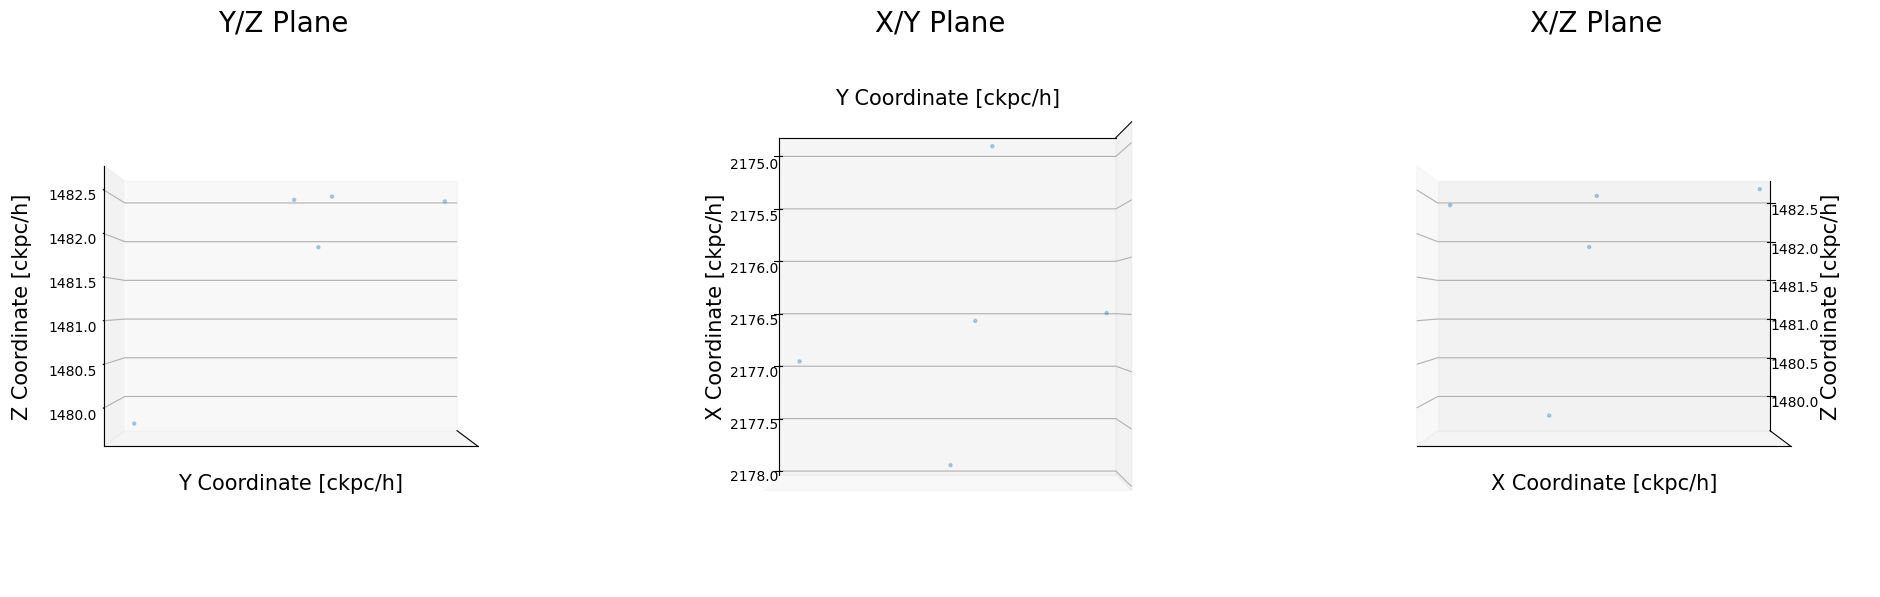

In [5]:
xdata = stars['Coordinates'][:,0]
ydata = stars['Coordinates'][:,1]
zdata = stars['Coordinates'][:,2]


vxdata = stars['Velocities'][:,0]
vydata = stars['Velocities'][:,1]
vzdata = stars['Velocities'][:,2]

print(len(stars['Coordinates']), len(stars['Velocities']))

massdata = stars['Masses']



massdata *= 1e10


print("Total mass of stars: ", np.sum(massdata), "Msun")

labelx = 'X Coordinate [ckpc/h]'
labely = 'Y Coordinate [ckpc/h]'
labelz = 'Z Coordinate [ckpc/h]'

fig = plt.figure()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'projection': '3d'}, figsize=(24, 8))


ax1.scatter(xdata[::100], ydata[::100], zdata[::100], marker='.', alpha=0.3)
ax1.view_init(elev=0, azim=0) 
ax1.set_ylabel(labely, size=15)
ax1.set_zlabel(labelz, size=15)
ax1.set_title('Y/Z Plane', size=20)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(axis='z', pad=8)
ax1.zaxis.labelpad = 20



ax2.scatter(xdata[::100], ydata[::100], zdata[::100], marker='.', alpha=0.3)
ax2.view_init(elev=90, azim=0) 
ax2.set_xlabel(labelx, size=15)
ax2.set_ylabel(labely, size=15)
ax2.set_title('X/Y Plane', size=20)
ax2.set_zticks([])
ax2.set_yticks([])
ax2.tick_params(axis='x', pad=8)
ax2.xaxis.labelpad = 20




ax3.scatter(xdata[::100], ydata[::100], zdata[::100], marker='.', alpha=0.3)
ax3.view_init(elev=0, azim=90) 
ax3.set_xlabel(labelx, size=15)
ax3.set_zlabel(labelz, size=15)
ax3.set_title('X/Z Plane', size=20)
ax3.set_yticks([])
ax3.set_xticks([])
ax3.tick_params(axis='z', pad=8)
ax3.zaxis.labelpad = 20
plt.show()


<Figure size 640x480 with 0 Axes>

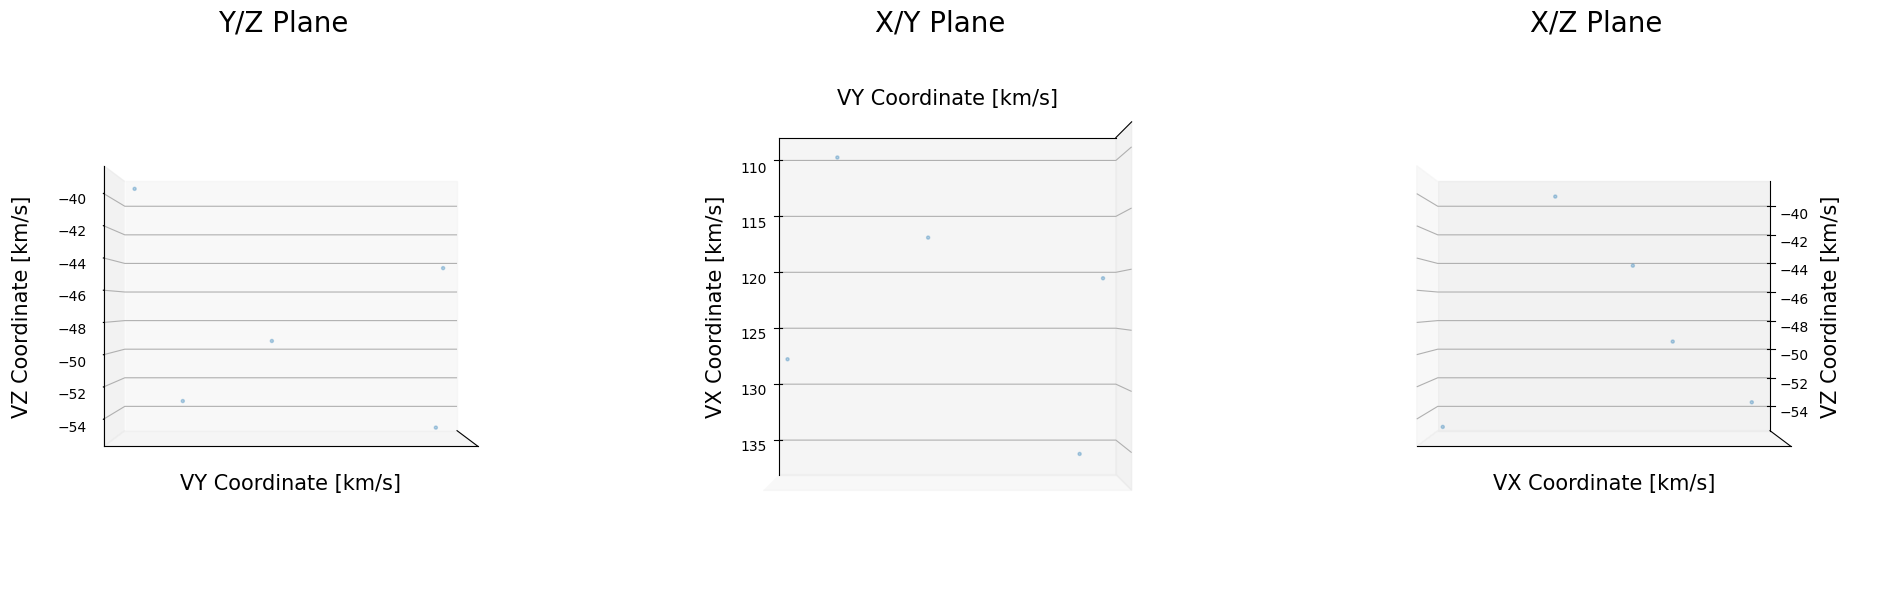

In [6]:



labelx = 'VX Coordinate [km/s]'
labely = 'VY Coordinate [km/s]'
labelz = 'VZ Coordinate [km/s]'


fig = plt.figure()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'projection': '3d'}, figsize=(24, 8))


ax1.scatter(vxdata[::100], vydata[::100], vzdata[::100], marker='.', alpha=0.3)
ax1.view_init(elev=0, azim=0) 
ax1.set_ylabel(labely, size=15)
ax1.set_zlabel(labelz, size=15)
ax1.set_title('Y/Z Plane', size=20)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(axis='z', pad=8)
ax1.zaxis.labelpad = 20



ax2.scatter(vxdata[::100], vydata[::100], vzdata[::100], marker='.', alpha=0.3)
ax2.view_init(elev=90, azim=0) 
ax2.set_xlabel(labelx, size=15)
ax2.set_ylabel(labely, size=15)
ax2.set_title('X/Y Plane', size=20)
ax2.set_zticks([])
ax2.set_yticks([])
ax2.tick_params(axis='x', pad=8)
ax2.xaxis.labelpad = 20




ax3.scatter(vxdata[::100], vydata[::100], vzdata[::100], marker='.', alpha=0.3)
ax3.view_init(elev=0, azim=90) 
ax3.set_xlabel(labelx, size=15)
ax3.set_zlabel(labelz, size=15)
ax3.set_title('X/Z Plane', size=20)
ax3.set_yticks([])
ax3.set_xticks([])
ax3.tick_params(axis='z', pad=8)
ax3.zaxis.labelpad = 20

plt.show()


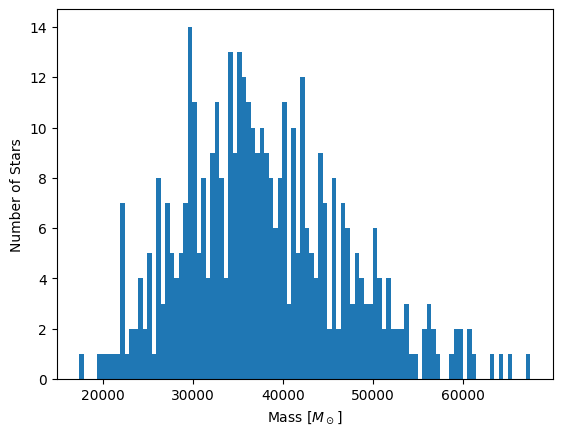

In [7]:
plt.hist(massdata, bins=100, label='Mass Distribution')
plt.xlabel('Mass [$M_\odot$]')
plt.ylabel('Number of Stars')
plt.show()

In [8]:
#USING WEBSITES EXTERNALLY MADE SUPPLEMENTARY CATALOGS FOR SUBHALO DATA

#THIS CATALOGE ONLY USES 𝑀_star > 3.4×10^8


filename = '/mnt/users/darnej/MPhys/TNG-50/stellar_circs.hdf5'

with h5py.File(filename, 'r') as f:

    key_99 = list(f.keys())[-1]
    print(key_99)

    data_99 = f[key_99]

    variables = defaultdict(list)

    for key in data_99.keys():
        variables[key].append(data_99[key][:])
        print(key)




Snapshot_99
CircAbove07Frac
CircAbove07Frac_allstars
CircAbove07MinusBelowNeg07Frac
CircAbove07MinusBelowNeg07Frac_allstars
CircTwiceBelow0Frac
CircTwiceBelow0Frac_allstars
MassTensorEigenVals
ReducedMassTensorEigenVals
SpecificAngMom
SpecificAngMom_allstars
SubfindID


(7904,)


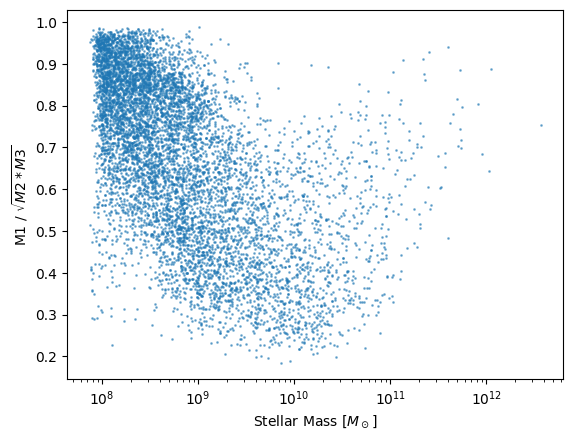

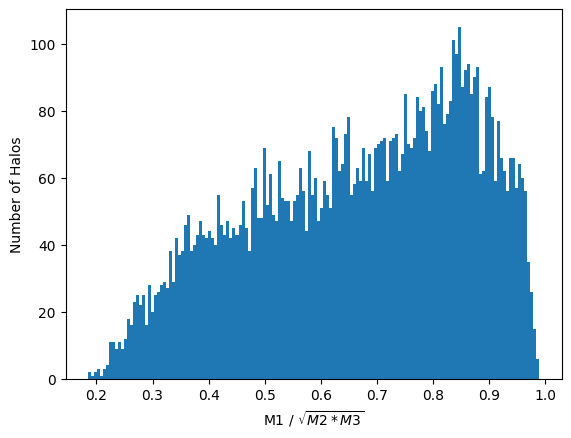

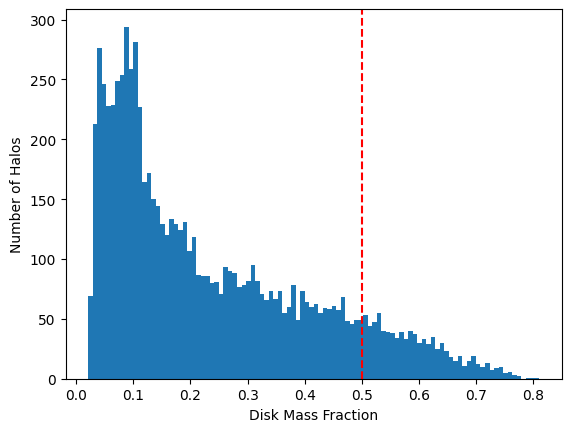

893


In [9]:
subhalo_ids = variables['SubfindID'][0]

print(subhalo_ids.shape)

disk_mass_frac = variables['CircAbove07Frac'][0]

mass_tensor_eigenvalues = variables['MassTensorEigenVals'][0]

M1 = mass_tensor_eigenvalues[:,0]
M2 = mass_tensor_eigenvalues[:,1]
M3 = mass_tensor_eigenvalues[:,2]

y = M1/np.sqrt(M2 * M3)

basePath = '/mnt/extraspace/rstiskalek/TNG50-1/output'
fields = ['SubhaloMassType', 'SubhaloMass']
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=fields)

stellar_mass_msun = np.array(subhalos['SubhaloMassType'])[:,4] * 1e10

stellar_mass_msun = stellar_mass_msun[subhalo_ids]

plt.scatter(stellar_mass_msun, y, s=1, alpha=0.5)
plt.xscale('log')
plt.xlabel('Stellar Mass [$M_\odot$]')
plt.ylabel('M1 / $\sqrt{M2 * M3}$')
plt.show()

plt.hist(y, bins=150, label='M1 / sqrt(M2 * M3) Distribution')
plt.xlabel('M1 / $\sqrt{M2 * M3}$')
plt.ylabel('Number of Halos')
plt.show()


plt.hist(disk_mass_frac, bins=100, label='Disk Mass Fraction Distribution')
plt.xlabel('Disk Mass Fraction')
plt.ylabel('Number of Halos')
plt.axvline(0.5, color='red', linestyle='--', label='0.5 Disk Mass Fraction')
plt.show()

mask = disk_mass_frac > 0.5

subhalo_ids = subhalo_ids[mask]
disk_mass_frac = disk_mass_frac[mask]

print(len(subhalo_ids))

In [10]:
fields = ['SubhaloMass', 'SubhaloMassType']
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=fields)

stellar_mass_msun = np.array(subhalos['SubhaloMassType'])[:,4] * 1e10

all_sub_halo_ids = range(len(stellar_mass_msun))

print(stellar_mass_msun.shape)

(5688113,)


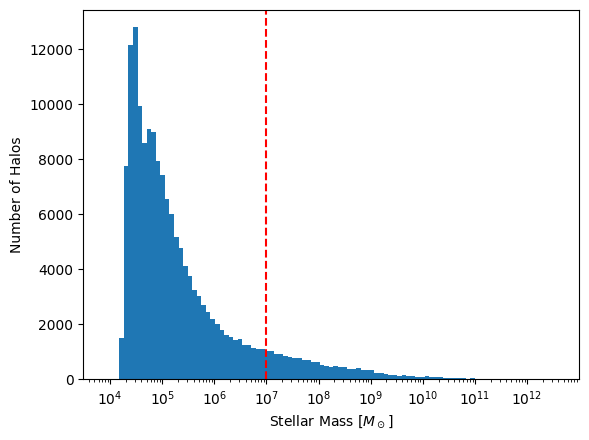

16933
16933


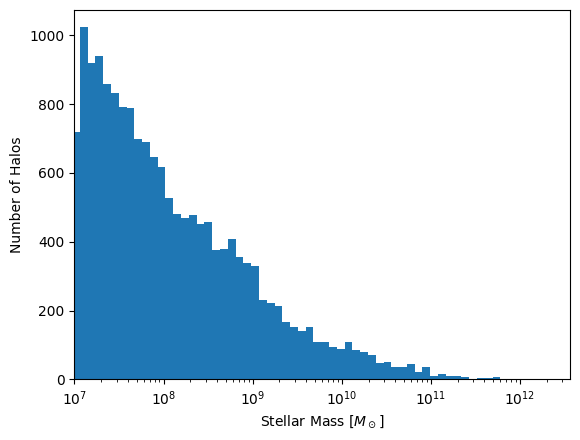

(16933,)


In [11]:
mask = stellar_mass_msun > 0
stellar_mass_msun = stellar_mass_msun[mask]
all_sub_halo_ids = np.array(all_sub_halo_ids)[mask]




logbins = np.logspace(np.log10(np.min(stellar_mass_msun)),np.log10(np.max(stellar_mass_msun)),100)
plt.hist(stellar_mass_msun, bins=logbins, label='Stellar Mass Distribution')
plt.xscale('log')
plt.xlabel('Stellar Mass [$M_\odot$]')
plt.ylabel('Number of Halos')

plt.axvline(1e7, color='red', linestyle='--', label='1e7 Msun')

plt.show()


mask = stellar_mass_msun > 1e7
stellar_mass_msun = stellar_mass_msun[mask]

all_sub_halo_ids = np.array(all_sub_halo_ids)[mask]


print(len(stellar_mass_msun))
print(len(all_sub_halo_ids))
plt.hist(stellar_mass_msun, bins=logbins, label='Stellar Mass Distribution')
plt.xscale('log')
plt.xlabel('Stellar Mass [$M_\odot$]')
plt.ylabel('Number of Halos')
plt.xlim(1e7, np.max(stellar_mass_msun))
plt.show()

print(all_sub_halo_ids.shape)

In [12]:
chosen_tng = []

for index in all_sub_halo_ids:
    if index in subhalo_ids:
        chosen_tng.append(index)

print(len(chosen_tng))
np.savetxt('sub_halo_ids.txt', chosen_tng, delimiter=',')

893


In [13]:

filename = '/mnt/users/darnej/MPhys/TNG-50/kinematic_decomposition_099.hdf5'

with h5py.File(filename, 'r') as f:

    key_99 = list(f.keys())[-1]
    print(key_99)

    data_99 = f[key_99]

    variables = defaultdict(list)

    for key in data_99.keys():
        variables[key].append(data_99[key][:])
        print(key)


class2_allstars
Bulge
ColdDisk
Disks
DiskyBulge
Halo
Spheroids
StellarMass
WarmDisk


(2813,)


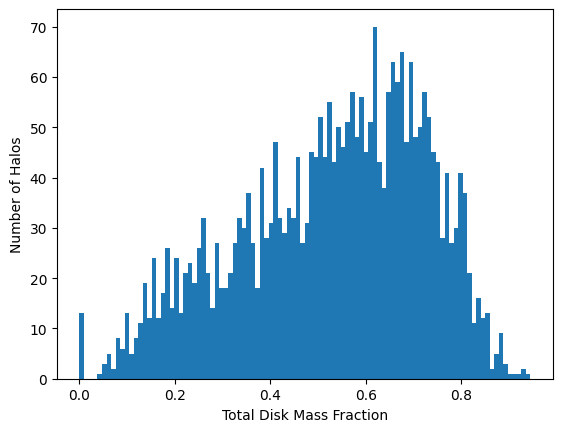

In [14]:
total_disk_mass_frac = variables['Disks'][0]

print(total_disk_mass_frac.shape)

plt.hist(total_disk_mass_frac, bins=100, label='Total Disk Mass Fraction Distribution')
plt.xlabel('Total Disk Mass Fraction')
plt.ylabel('Number of Halos')
plt.show()
        

In [3]:
#TRYING AGAIN USING TARIQS METHOD


basePath = '/mnt/extraspace/rstiskalek/TNG50-1/output'
fields = ['SubhaloCM']
subhalos_CM = il.groupcat.loadSubhalos(basePath,99,fields=fields)




In [4]:
print(subhalos_CM.shape)
counter = 0

allowed_indexes = []

for i in range(len(subhalos_CM[:])):
    COM = np.column_stack((subhalos_CM[i][0], subhalos_CM[i][1], subhalos_CM[i][2]))
    COM = COM[0]
    if COM[0] <= 16000 and COM[1] <= 16000 and COM[2] <= 16000 and COM[0] >= 0 and COM[1] >= 0 and COM[2] >= 0:
        counter += 1
        allowed_indexes.append(i)
    

(5688113, 3)


In [5]:
print(counter)

421425


16089460.0
(421425,)
(10089,)


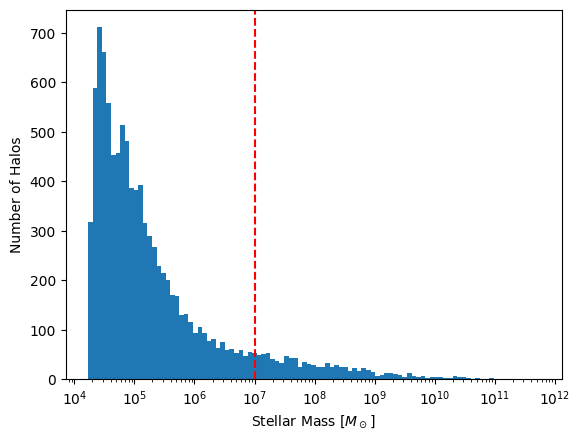

In [8]:

basePath = '/mnt/extraspace/rstiskalek/TNG50-1/output'
fields = ['SubhaloMassType']
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=fields)

stellar_mass_msun = np.array(subhalos)[:,4] * 1e10

print(stellar_mass_msun[536684])

stellar_mass_msun = stellar_mass_msun[allowed_indexes]
print(stellar_mass_msun.shape)

mask = stellar_mass_msun > 0
stellar_mass_msun = stellar_mass_msun[mask]
all_sub_halo_ids = np.array(allowed_indexes)[mask]
print(stellar_mass_msun.shape)

logbins = np.logspace(np.log10(np.min(stellar_mass_msun)),np.log10(np.max(stellar_mass_msun)),100)

plt.hist(stellar_mass_msun, bins=logbins, label='Stellar Mass Distribution')
plt.xscale('log')
plt.xlabel('Stellar Mass [$M_\odot$]')
plt.ylabel('Number of Halos')
plt.axvline(1e7, color='red', linestyle='--', label='1e7 Msun')
plt.show()

mask = stellar_mass_msun > 1e7

stellar_mass_msun = stellar_mass_msun[mask]

all_sub_halo_ids = np.array(all_sub_halo_ids)[mask]

In [9]:
print(len(all_sub_halo_ids))

np.savetxt('sub_halo_ids.txt', all_sub_halo_ids, delimiter=',')

995


In [ ]:
from scipy import constants
from scipy.optimize import curve_fit, OptimizeWarning

chosen_gals = np.loadtxt('Chosen_galaxies_TNG.txt')

gal_number = int(chosen_gals[2])


print(gal_number)

import sys
sys.path.append('/mnt/users/darnej/MPhys/')
import importlib
import dynamics
importlib.reload(dynamics)


dataframe = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')

gas_r_half = dataframe['gas_r_half'][dataframe['gal_number'] == gal_number].values[0]  # R_1/2 for the galaxy

from dynamics import load_all_data_TNG

star_data, dm_data, gas_data  = load_all_data_TNG(int(gal_number))
        
Msun = 1.989e30
kpc_to_m = 3.086e19
kpc_to_km = 3.086e16

Msun_to_H = 1.9885e30/ 1.6726219e-27  # Convert solar mass to hydrogen atoms
kpc_to_cm = 3.086e21  # Convert kpc to cm


if len(star_data['positions']) == 0 or len(star_data['velocities']) == 0:
    print('No data found for galaxy number: ', gal_number)

#Variables with dm infront are from dm and any without are from the baryonic matter

xdata = star_data['positions'][:, 0]
ydata = star_data['positions'][:, 1]
zdata = star_data['positions'][:, 2]

vxdata = star_data['velocities'][:, 0]
vydata = star_data['velocities'][:, 1]
vzdata = star_data['velocities'][:, 2]

massdata = np.array(star_data['masses'])

stellar_mass = np.sum(massdata)
print('Stellar mass of the galaxy is: ', stellar_mass)

if stellar_mass == 0:
    print('No stellar mass found for galaxy number: ', gal_number)

#DM data

dm_xdata = dm_data['positions'][:, 0]
dm_ydata = dm_data['positions'][:, 1]
dm_zdata = dm_data['positions'][:, 2]

dm_vxdata = dm_data['velocities'][:, 0]
dm_vydata = dm_data['velocities'][:, 1]
dm_vzdata = dm_data['velocities'][:, 2]

dm_massdata = np.array(dm_data['masses'])

dm_mass = np.sum(dm_massdata)
print('Dark matter mass of the galaxy is: ', dm_mass)

#Gas data

gas_xdata = gas_data['positions'][:, 0]
gas_ydata = gas_data['positions'][:, 1]
gas_zdata = gas_data['positions'][:, 2]

gas_vxdata = gas_data['velocities'][:, 0]
gas_vydata = gas_data['velocities'][:, 1]
gas_vzdata = gas_data['velocities'][:, 2]

gas_velocities = np.column_stack((gas_vxdata, gas_vydata, gas_vzdata))
gas_positions = np.column_stack((gas_xdata, gas_ydata, gas_zdata))

gas_masses = np.array(gas_data['masses'])

gas_densities = np.array(gas_data['densities'])

H1_frac = np.array(gas_data['H1_frac'])

H1_masses = gas_masses * H1_frac

H1_densities = gas_densities * H1_frac

h1_positions = gas_positions
h1_velocities = gas_velocities
h1_masses = H1_masses
h1_densities = H1_densities


Msun = 1.989e30
kpc_to_m = 3.086e19
kpc_to_km = 3.086e16

#Calculate the distance from the centre of the galaxy

rdata = np.sqrt(xdata**2 + ydata**2 + zdata**2)
dm_rdata = np.sqrt(dm_xdata**2 + dm_ydata**2 + dm_zdata**2)

points = np.column_stack((xdata, ydata, zdata))
dm_points = np.column_stack((dm_xdata, dm_ydata, dm_zdata))

#Need to move into center of mass frame of the galaxy

velocities = np.column_stack((vxdata, vydata, vzdata))
dm_velocities = np.column_stack((dm_vxdata, dm_vydata, dm_vzdata))


#Sort the data by distance from the centre of the galaxy
#Create an array called mapping which has the final after its sorted in terms of distance, therefore any other data can be sorted in the same way

from dynamics import create_rotation_matrix

rotation_matrix = create_rotation_matrix(h1_velocities, h1_positions, h1_masses, False)

if np.isnan(rotation_matrix).any():
    print('Rotation matrix contains NaN values for galaxy number: ', gal_number)

#Now apply the rotation matrix to the velocity vectors

velocities_rotated = np.dot(rotation_matrix, velocities[:][:].T).T
rotated_points = np.dot(rotation_matrix, points[:][:].T).T

gas_velocities_rotated = np.dot(rotation_matrix, gas_velocities.T).T
gas_positions_rotated = np.dot(rotation_matrix, gas_positions.T).T

h1_velocities_rotated = np.dot(rotation_matrix, h1_velocities.T).T
h1_positions_rotated = np.dot(rotation_matrix, h1_positions.T).T

dm_velocities_rotated = np.dot(rotation_matrix, dm_velocities[:][:].T).T
dm_rotated_points = np.dot(rotation_matrix, dm_points[:][:].T).T

x = np.log10(h1_densities) + np.log10(Msun_to_H / (kpc_to_cm**3))  # Convert densities to log scale
h1_densities = 10**x  # Convert back to linear scale


mask = h1_densities > 0.01
h1_velocities_rotated = h1_velocities_rotated[mask]
h1_positions_rotated = h1_positions_rotated[mask]
h1_masses = h1_masses[mask]
h1_densities = h1_densities[mask]

velocities_rotated = np.append(velocities_rotated, gas_velocities_rotated, axis=0)
rotated_points = np.append(rotated_points, gas_positions_rotated, axis=0)
massdata = np.append(massdata, gas_masses)

rdata = np.append(rdata, np.sqrt(gas_positions[:,0]**2 + gas_positions[:,1]**2 + gas_positions[:,2]**2))


#Do some plots of the gas particles 

from dynamics import Plot_3d_scatter_with_dm
from dynamics import Plot_3d_scatter
from dynamics import create_quiver_graph
from dynamics import create_quiver_graph_with_vel

x_label = 'X Coordinate [kpc]'
y_label = 'Y Coordinate [kpc]'
z_label = 'Z Coordinate [kpc]'

Plot_3d_scatter(gas_positions_rotated[:,0], gas_positions_rotated[:,1], gas_positions_rotated[:,2], x_label, y_label, z_label, 'Galaxy ' + str(gal_number) + ' Gas Particles')

gas_angular_mom = np.cross(gas_positions_rotated, gas_velocities_rotated) * gas_masses[:, np.newaxis]
tot_gas_ang_mom = np.sum(gas_angular_mom, axis=0)
colors = np.array(['blue'] * (len(gas_positions_rotated[::100])))
colors = np.append(colors, ['red'], axis=0)  # Add a red color for the angular momentum vector
plot_gas = gas_positions_rotated[::100]
plot_gas = np.append(plot_gas, [[0,0,0]], axis = 0)
plot_gas_vel = gas_velocities_rotated[::100]*2 / np.linalg.norm(gas_velocities_rotated[::100], axis=1)[:, np.newaxis]  # Normalize the velocities
plot_gas_vel = np.append(plot_gas_vel, [(tot_gas_ang_mom * 2 / np.linalg.norm(tot_gas_ang_mom))], axis = 0)

limits = [-20, 20]

create_quiver_graph_with_vel(plot_gas_vel, plot_gas, colors, limits)



Plot_3d_scatter(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2], x_label, y_label, z_label, 'Galaxy ' + str(gal_number) + ' Star and Gas Particles')
Plot_3d_scatter_with_dm(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2], dm_rotated_points[:,0], dm_rotated_points[:,1], dm_rotated_points[:,2], x_label, y_label, z_label, 'Galaxy ' + str(gal_number) + ' Star, gas and DM Particles')

#Now we want to change the velocities from cartesian to cylindrical coordinates
#If r = sqrt(x^2 + y^2) then vr = (x(xdot) + y(ydot))/r
#If tan(theta) = y/x then vtheta = ((ydot)x - y(xdot))/r^2

def cartesian_to_cylindrical_velocity(vx, vy, vz, x, y):
    vr = (x*vx + y*vy)/(x**2 + y**2)**0.5
    vtheta = (x*vy - y*vx)/(x**2 + y**2)**0.5
    vz = vz
    return np.array([vr, vtheta, vz]).T


h1_cylindrical_velocities = cartesian_to_cylindrical_velocity(h1_velocities_rotated[:,0],h1_velocities_rotated[:,1], h1_velocities_rotated[:,2], h1_positions_rotated[:,0], h1_positions_rotated[:,1])

v_theta_h1 = h1_cylindrical_velocities[:,1]


#Now need to convert the points from cartesian to cylindrical coordinates

def cartesian_to_cylindrical_points(x, y, z):
    r = (x**2 + y**2)**0.5
    theta = np.arctan2(y, x)
    z = z
    return np.array([r, theta, z]).T

gas_cylindrical_points = cartesian_to_cylindrical_points(gas_positions_rotated[:,0], gas_positions_rotated[:,1], gas_positions_rotated[:,2])

gas_cylindrical_shells = gas_cylindrical_points[:,0] #r points

h1_cylindrical_points = cartesian_to_cylindrical_points(h1_positions_rotated[:,0], h1_positions_rotated[:,1], h1_positions_rotated[:,2])

h1_cylindrical_shells = h1_cylindrical_points[:,0] #r points


#FINDING ALL ACCELERATIONS AND VELOCITIES

#Want 30 bins between r = 0 and r = 5*Rgas_1/2


dataframe = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')

gal_numbers = np.array(dataframe['gal_number'])

R_1_2 = dataframe['gas_r_half'][gal_numbers == gal_number].values[0]

gas_z_half = dataframe['gas_z_half'][gal_numbers == gal_number].values[0]


number_of_bins = 30

bins = np.linspace(0, 5*R_1_2, number_of_bins+1)
bincenters = (bins[1:] + bins[:-1])/2


mean_acc_obs = []
mean_acc_bar = []
total_mean_acc_bar = []
v_obs = []


sigma = []
mean_r = []
surface_density = []


## V_A2 = R * Sigma_p^2 * e^(R/R_d) / R_d * (R_c/arcsec + e^(R/R_d))^-1

#For each bin we have R, need to get a value for sigma_p, R_d and R_c

#Sigma_p is the velocity dispersion for that bin. It is calculated by sigma_p^2 = np.sum(v[i] - mean_v_theta_in_bin)**2 / (len(v_theta_in_bin) - 1)
def get_sigma_p(v):
    mean_v = np.mean(v, axis=0)
    sigma_p_squared = np.sum(((v - mean_v) ** 2) / len(v), axis = 0)
    return np.sqrt(sigma_p_squared)

def surface_density_model(R, f0, Rc, Rd):
    x = R / Rd
    exp_term = np.exp(x)
    # # Use stable form when exp(x) is huge
    # exp_term = np.exp(np.minimum(x, 700))
    return f0 * (Rc + 1) * (Rc + exp_term)**(-1) # Example for illustration



for i in range(number_of_bins):


    max_r_for_bin = bins[i+1]
    min_r_for_bin = bins[i]

    mask = (h1_cylindrical_shells > min_r_for_bin) & (h1_cylindrical_shells < max_r_for_bin)

    v_in_bin = h1_cylindrical_velocities[mask]

    vtheta_in_bin = v_theta_h1[mask]

    mass_in_bin = h1_masses[mask]

    if len(vtheta_in_bin) > 1:

        #FINDING V_OBS AND G_OBS

        mean_v_theta_in_bin = np.average(vtheta_in_bin, weights=mass_in_bin)

        v_obs.append(mean_v_theta_in_bin)

        mean_a_in_bin = np.average(vtheta_in_bin**2 / h1_cylindrical_shells[mask], weights=mass_in_bin)

        mean_acc_obs.append(mean_a_in_bin)

        #CALCULATE ASYMMETRIC VELOCITY DRIFT


        sigma_in_bin = get_sigma_p(v_in_bin)

        sigma.append(sigma_in_bin)

        surface_dens = np.sum(mass_in_bin) / (np.pi * (max_r_for_bin**2 - min_r_for_bin**2))

        surface_density.append(surface_dens)

        mean_r.append(bincenters[i])


        #FINDING G_BAR AND V_BAR

        r_in_m = bincenters[i]*kpc_to_m
        mask = (rdata < bincenters[i])
        x = Msun / r_in_m**2
        x = x * constants.G * np.sum(massdata[mask])
        mean_acc_bar.append(x)


        #FINDING G_TOTAL AND V_TOTAL


        dm_mask = (dm_rdata < bincenters[i])
        mask = (rdata < bincenters[i])
        x = Msun / r_in_m**2
        x = x * constants.G * (np.sum(massdata[mask]) + np.sum(dm_massdata[dm_mask]))
        total_mean_acc_bar.append(x)



    else:
        continue

        

mean_acc_obs = np.array(mean_acc_obs)*kpc_to_m

mean_acc_bar = np.array(mean_acc_bar)

v_obs = np.array(v_obs)

total_mean_acc_bar = np.array(total_mean_acc_bar)

sigma = np.array(sigma)

surface_density = np.array(surface_density)

mean_r = np.array(mean_r)


sigma_v = np.sqrt(sigma[:,0]**2 + sigma[:,1]**2 + sigma[:,2]**2)

sigma2_SD = sigma_v**2 * surface_density #Units: Msun/s^2


#FIND V_A USING F FITTING FUNCTION

# Initial guess for the parameters (f_0, Rc, Rd)

p0 = [sigma2_SD[0], 5, 5] 

if len(mean_r) < 3:
    print("Not enough data points for curve fitting. Ensure you have sufficient data in your bins.")
    
try:
    # popt contains the optimal values for the parameters
    # pcov is the covariance matrix
    popt, pcov = curve_fit(surface_density_model, mean_r, sigma2_SD, p0=p0)

    # Extract the fitted parameters
    fitted_f0, fitted_Rc, fitted_Rd = popt
    print(f"Fitted Rc: " + str(fitted_Rc))
    print(f"Fitted Rd: " + str(fitted_Rd))
    print(f"Fitted f0: " + str(fitted_f0))

# You can then use these fitted_Rc and fitted_Rd values in your V_A calculation.
except RuntimeError as e:
    print(f"Error during curve fitting: {e}")
    print("Try adjusting initial guesses (p0) or checking your data.")

    results = defaultdict(list)

    results['mean_acc_obs'] = mean_acc_obs
    results['mean_acc_bar'] = mean_acc_bar
    results['mean_vtheta'] = v_obs
    results['mean_r'] = bincenters
    results['total_mean_acc_bar'] = total_mean_acc_bar


VA2 = mean_r * (sigma_v**2 * np.exp(mean_r / fitted_Rd)) / (fitted_Rd * (fitted_Rc + np.exp(mean_r / fitted_Rd)))

V_C = np.sqrt(v_obs**2 + VA2**2)

g_obs = (V_C**2 /(mean_r)) * kpc_to_m

results = defaultdict(list)

results['mean_acc_obs'] = mean_acc_obs
results['mean_acc_bar'] = mean_acc_bar
results['mean_vtheta'] = v_obs
results['mean_r'] = bincenters
results['total_mean_acc_bar'] = total_mean_acc_bar
results['g_obs'] = g_obs



: 

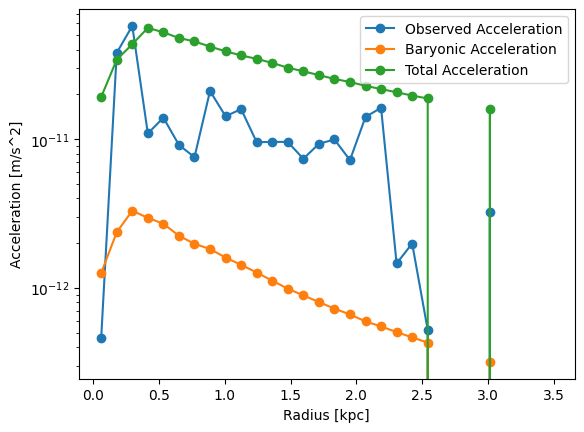

/tmp/ipykernel_1798470/4091329170.py:22: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(mean_acc_bar), np.log10(mean_acc_obs), label='Observed vs Baryonic Acceleration', marker='o')


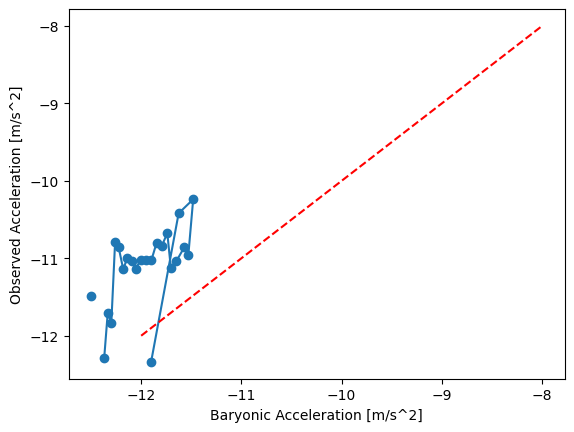

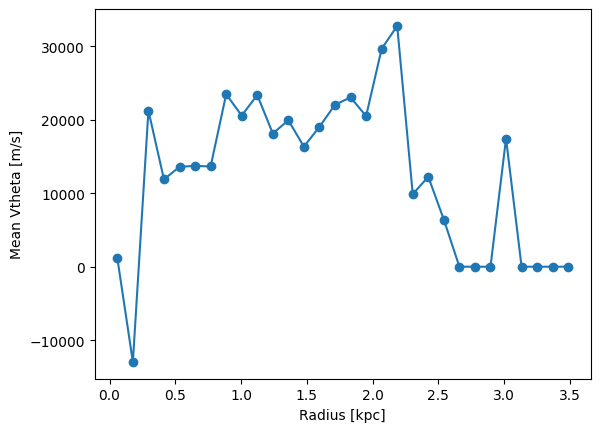

In [7]:
bincenters = results['mean_r']
mean_acc_obs = results['mean_acc_obs']
mean_acc_bar = results['mean_acc_bar']
total_mean_acc_bar = results['total_mean_acc_bar']
mean_v_theta = results['mean_vtheta']
v_sigma = results['v_sigma']


plt.plot(bincenters, mean_acc_obs, label='Observed Acceleration', marker='o')
plt.plot(bincenters, mean_acc_bar, label='Baryonic Acceleration', marker='o')
plt.plot(bincenters, total_mean_acc_bar, label='Total Acceleration', marker='o')

plt.yscale('log')
plt.xlabel('Radius [kpc]')
plt.ylabel('Acceleration [m/s^2]')
plt.legend()
plt.show()


x = np.linspace(-12, -8, 100)
y = x
plt.plot(np.log10(mean_acc_bar), np.log10(mean_acc_obs), label='Observed vs Baryonic Acceleration', marker='o')
plt.plot(x, y, color='red', linestyle='--', label='y = x (Perfect Match)')
plt.xlabel('Baryonic Acceleration [m/s^2]')
plt.ylabel('Observed Acceleration [m/s^2]')
plt.show()


plt.plot(bincenters, mean_v_theta, label='Mean Vtheta', marker='o')
plt.xlabel('Radius [kpc]')
plt.ylabel('Mean Vtheta [m/s]')
plt.show()



1


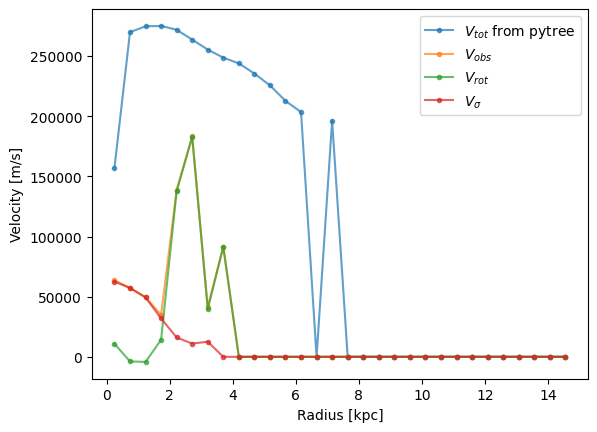

In [4]:
#PLOTTING VOBS VROT AND VSIGMA
v_obs = np.sqrt(mean_v_theta**2 + v_sigma**2)


directory = '/mnt/users/darnej/MPhys/TNG-50/pytree_results'

files = glob.glob(directory + '/*_' + str(gal_number) + '.csv')

print(len(files))

if len(files) == 0:
    print('No pytree files found for galaxy number: ', gal_number)

else:
    pytree_file = files[0]
    pytree_data = pd.read_csv(pytree_file)
    g_tot_pytree = pytree_data['mean_a_r_total_py']
    v_tot_pytree = np.sqrt(g_tot_pytree * bincenters * kpc_to_m)
    plt.plot(bincenters, v_tot_pytree, label='$V_{tot}$ from pytree', marker = '.', alpha = 0.7)

#v_tot_sph = np.sqrt(total_mean_acc_bar * bincenters * kpc_to_m)


plt.plot(bincenters, v_obs, label='$V_{obs}$', marker = '.', alpha = 0.7)
#plt.plot(bincenters, v_tot_sph, label='$V_{tot}$ from sph', marker = '.', alpha = 0.7)
plt.plot(bincenters, mean_v_theta, label='$V_{rot}$', marker = '.', alpha = 0.7)
plt.plot(bincenters, v_sigma, label='$V_{\sigma}$', marker = '.', alpha = 0.7)

plt.xlabel('Radius [kpc]')
plt.ylabel('Velocity [m/s]')
plt.legend()
plt.show()

In [13]:
import sys

sys.path.append('/mnt/users/darnej/MPhys/')

import importlib
import RAR_for_all_chosen
importlib.reload(RAR_for_all_chosen)

from RAR_for_all_chosen import run

ozy_file = 'lol'
results = run(int(gal_number), ozy_file, sim = 'TNG')

Stellar mass of the galaxy is:  2842842600.0
Dark matter mass of the galaxy is:  33190200000.0
[[-0.09050662 -0.60152988 -0.79370672]
 [-0.60152988  0.66819257 -0.43781331]
 [ 0.79370672  0.43781331 -0.42231405]]
OPTIMIZE WARNING: Curve fitting did not converge. Check your data or initial parameters.


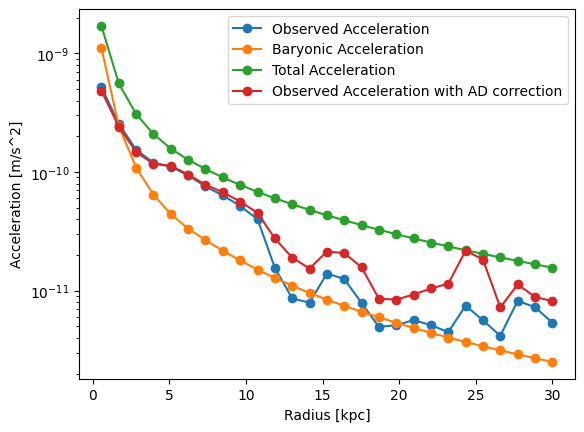

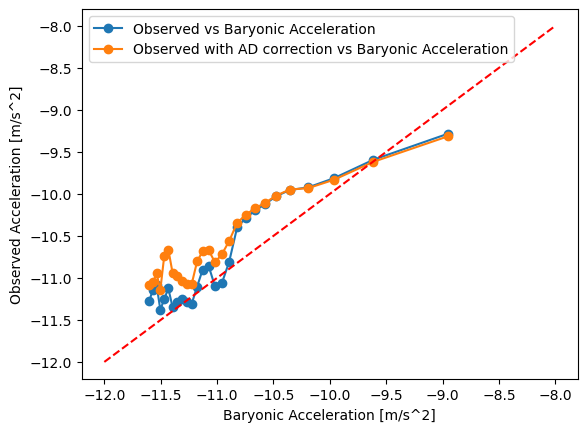

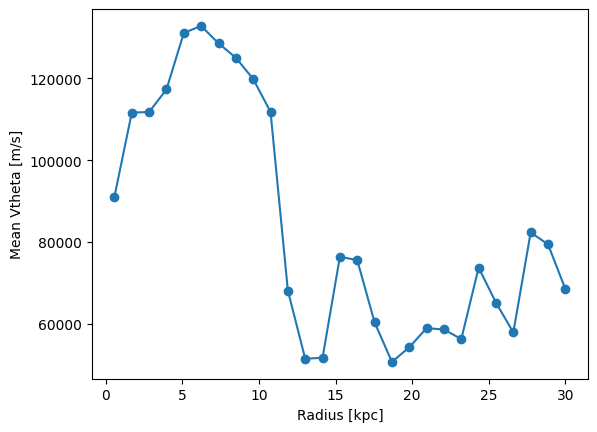

In [32]:
bincenters = results['mean_r']
mean_acc_obs = results['mean_acc_obs']
mean_acc_bar = results['mean_acc_bar']
total_mean_acc_bar = results['total_mean_acc_bar']
mean_v_theta = results['mean_vtheta']
g_obs = results['g_obs']


bincenters = bincenters[0:len(mean_acc_obs)]


plt.plot(bincenters, mean_acc_obs, label='Observed Acceleration', marker='o')
plt.plot(bincenters, mean_acc_bar, label='Baryonic Acceleration', marker='o')
plt.plot(bincenters, total_mean_acc_bar, label='Total Acceleration', marker='o')
plt.plot(bincenters, g_obs, label='Observed Acceleration with AD correction', marker='o')

plt.yscale('log')
plt.xlabel('Radius [kpc]')
plt.ylabel('Acceleration [m/s^2]')
plt.legend()
plt.show()


x = np.linspace(-12, -8, 100)
y = x
plt.plot(np.log10(mean_acc_bar), np.log10(mean_acc_obs), label='Observed vs Baryonic Acceleration', marker='o')
plt.plot(np.log10(mean_acc_bar), np.log10(g_obs), label='Observed with AD correction vs Baryonic Acceleration', marker='o')
plt.legend()
plt.plot(x, y, color='red', linestyle='--', label='y = x (Perfect Match)')
plt.xlabel('Baryonic Acceleration [m/s^2]')
plt.ylabel('Observed Acceleration [m/s^2]')
plt.show()


plt.plot(bincenters, mean_v_theta, label='Mean Vtheta', marker='o')
plt.xlabel('Radius [kpc]')
plt.ylabel('Mean Vtheta [m/s]')
plt.show()


In [22]:
basePath = '/mnt/extraspace/rstiskalek/TNG50-1/output'

gas = il.snapshot.loadSubhalo(basePath,99,220596,'gas')
print(gas.keys())



dict_keys(['count', 'CenterOfMass', 'Coordinates', 'Density', 'ElectronAbundance', 'EnergyDissipation', 'GFM_AGNRadiation', 'GFM_CoolingRate', 'GFM_Metallicity', 'GFM_Metals', 'GFM_MetalsTagged', 'GFM_WindDMVelDisp', 'GFM_WindHostHaloMass', 'InternalEnergy', 'InternalEnergyOld', 'Machnumber', 'MagneticField', 'MagneticFieldDivergence', 'Masses', 'NeutralHydrogenAbundance', 'ParticleIDs', 'Potential', 'StarFormationRate', 'SubfindDMDensity', 'SubfindDensity', 'SubfindHsml', 'SubfindVelDisp', 'Velocities'])


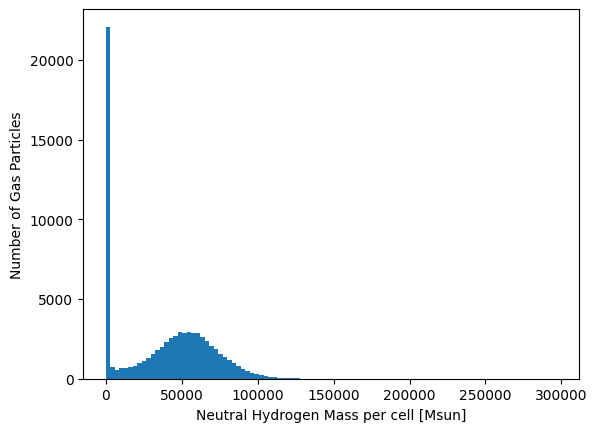

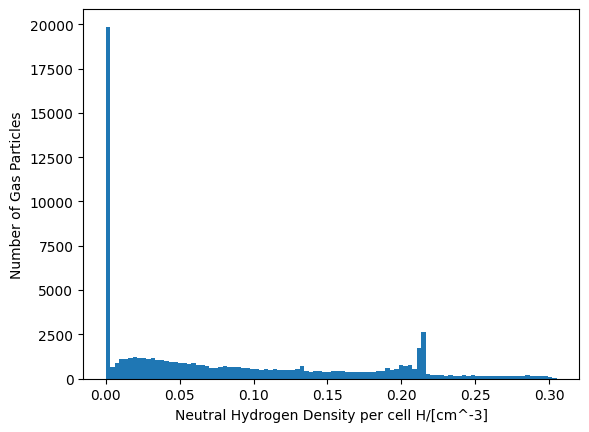

In [23]:
H_frac = gas['NeutralHydrogenAbundance']
gas_density = gas['Density'] * 1e10
gas_masses = gas['Masses'] * 1e10

Msun_to_H = 1.989e30/1.67e-27  # Solar mass in kg
kpc_to_cm = 3.086e21  # Conversion factor from kiloparsecs to centimeters

x = Msun_to_H / kpc_to_cm**3  # Convert density to number density of hydrogen atoms

gas_density = gas_density * x  # Convert density to number density of hydrogen atoms

H_density = gas_density * H_frac # Hydrogen number density

plt.hist(H_frac * gas_masses, bins=100, label='Neutral Hydrogen Abundance Distribution')
plt.xlabel('Neutral Hydrogen Mass per cell [Msun]')
plt.ylabel('Number of Gas Particles')
plt.show()

plt.hist(H_density, bins=100, label='Neutral Hydrogen Distribution')
plt.xlabel('Neutral Hydrogen Density per cell H/[cm^-3]')
plt.ylabel('Number of Gas Particles')
plt.show()




   ___                                           _  _             
  /___\ ____ _   _  _ __ ___    __ _  _ __    __| |(_)  __ _  ___ 
 //  //|_  /| | | || '_ ` _ \  / _` || '_ \  / _` || | / _` |/ __|
/ \_//  / / | |_| || | | | | || (_| || | | || (_| || || (_| |\__ \
\___/  /___| \__, ||_| |_| |_| \__,_||_| |_| \__,_||_| \__,_||___/
             |___/                                                

   (C) 2021 F. Rodriguez Montero
   Version 0.2.dev1

/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/ozy_00925.hdf5
1
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_2.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_2.hdf5
CM of star_data is at (55502.351702949156 kpc, 55078.25701024228 kpc, 56951.019030144795 kpc)
CM of gas_data is at (0.4880524837813812, 0.48432326399549075, 0.5007911455770975)


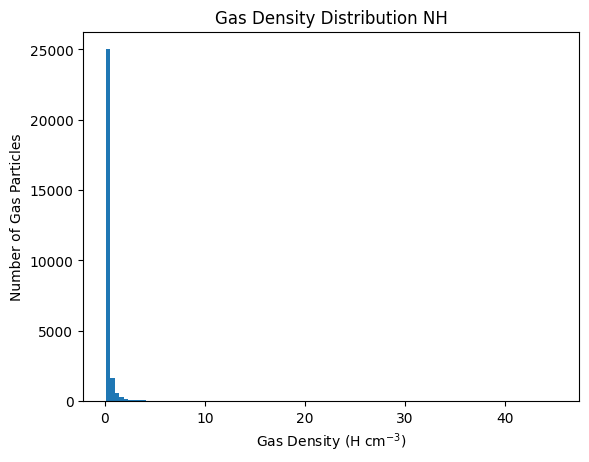

In [24]:

import glob
import os
import ozy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from collections import defaultdict
import scipy.constants as constants

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]

print(ozy_file)

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

gal = 2

stars_files = []
for filename in glob.glob(os.path.join(directory, '*star*_' + str(gal) + '.hdf5')):
    stars_files.append(filename)

dm_files = []
for filename in glob.glob(os.path.join(directory, '*dm*_' + str(gal) + '.hdf5')):
    dm_files.append(filename)


directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

gas_files = glob.glob(os.path.join(directory, '*_' + str(gal) + '.hdf5'))


stars_files.sort()
dm_files.sort()
gas_files.sort()

print(len(stars_files))



from dynamics import load_all_data

star_filename = stars_files[0]
dm_filename = dm_files[0]
print(star_filename)
print(dm_filename)
gas_filename = gas_files[0]

star_data, dm_data, gas_data, mass_multiplier, length_multiplier, time_multiplier = load_all_data(star_filename, dm_filename, gas_filename, ozy_file)

gas_positions = np.column_stack((gas_data['x'], gas_data['y'], gas_data['z']))
gas_velocities = np.column_stack((gas_data['vx'], gas_data['vy'], gas_data['vz']))
gas_masses = gas_data['mass']

gas_densities = gas_data['density']

Msun_to_H = 1.989e30/1.67e-27
kpc_to_cm = 3.086e21

gas_densities = gas_densities * Msun_to_H / kpc_to_cm**3
plt.hist(gas_densities, bins=100)
plt.xlabel('Gas Density (H cm$^{-3}$)')
plt.ylabel('Number of Gas Particles')
plt.title('Gas Density Distribution NH')
plt.show()


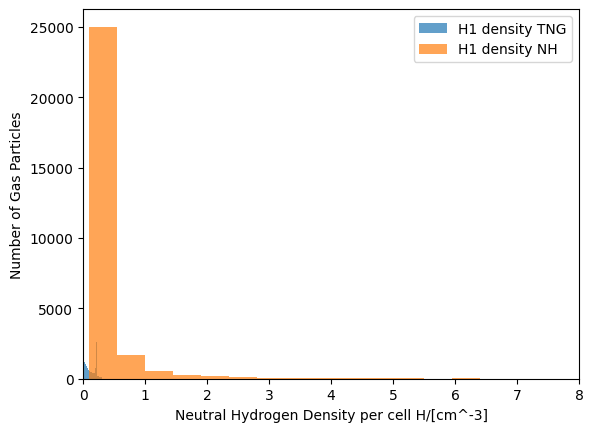

In [26]:

plt.hist(H_density, bins=100, label='H1 density TNG', alpha=0.7)
plt.hist(gas_densities, bins=100, label='H1 density NH', alpha=0.7)
plt.xlabel('Neutral Hydrogen Density per cell H/[cm^-3]')
plt.ylabel('Number of Gas Particles')
plt.xlim(0,8)
plt.legend()
plt.show()